# Check whether the model is working

**NOTES:**
- The model needs finetuning before being evaluated.
- Currently only numerical features can be used


In [1]:
import sys

sys.path.append("../")
import shap
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from explainerpfn.base import ExplainerPFN
from explainerpfn.temp import (
    get_data,
    get_shap_values,
    preprocess_data,
    analyze_correlation_results,
    plot_explanations,
)
from explainerpfn.utils import explanation_correction

# just a simple toy dataset (all continuous features)
df, df_train_rf, df_train, df_test = get_data("SPAMBASE")

cols_to_drop = df.columns[4:-1]
df = df.drop(columns=cols_to_drop)
df_train_rf = df_train_rf.drop(columns=cols_to_drop)
df_train = df_train.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

(X_train_rf, y_train_rf), (X_train, y_train), (X_test, y_test) = preprocess_data(
    df_train_rf, df_train, df_test
)

clf = MLPClassifier(
    max_iter=2000, alpha=0.05, learning_rate="invscaling", random_state=42
)
clf.fit(X_train_rf, y_train_rf)

y_train = clf.predict_proba(X_train)[:, 1]
y_test = clf.predict_proba(X_test)[:, 1]

all_shap_values = []
for X, y in tqdm(
    list(zip([X_train, X_test], [y_train, y_test])), desc="Calculating SHAP values"
):
    xai = shap.Explainer(model=clf.predict_proba, masker=X_train)
    X_shap = xai(X).values[:, :, -1]

    df_shap = pd.DataFrame(X_shap.astype(float), columns=X.columns)
    df_shap["target"] = y
    all_shap_values.append((X_shap, df_shap))

(X_train_shap, df_shap_train), (X_test_shap, df_shap_test) = all_shap_values

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating SHAP values:   0%|          | 0/2 [00:00<?, ?it/s]

In [2]:
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)
explanations = xai.predict(X_test.values, y_test)

In [3]:
explanations_corrected = explanation_correction(
    explanations,
    y_test,
    xai.base_value_,
    adjust_std=True,
    process_outliers=True,
    std_multiplier=2,
)

In [5]:
analyze_correlation_results(
    df, df_shap, explanations, explanations_corrected, y_test, df_train
)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,pfn_exp_corr_vs_target,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,0.126208,0.503685,0.794006,0.617855,0.582290,0.356152
1,-0.030224,0.750538,0.675395,0.583014,0.487657,0.506539
2,0.196988,0.842949,0.861578,0.689730,0.782023,0.515347
3,0.057371,0.163790,0.746352,0.797534,-0.001765,-0.049244
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


(<Figure size 2400x600 with 4 Axes>,
 array([<Axes: xlabel='Input values distribution', ylabel='Frequency'>,
        <Axes: xlabel='PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='Corrected PFN explanations distribution', ylabel='Frequency'>,
        <Axes: xlabel='SHAP values distribution', ylabel='Frequency'>],
       dtype=object))

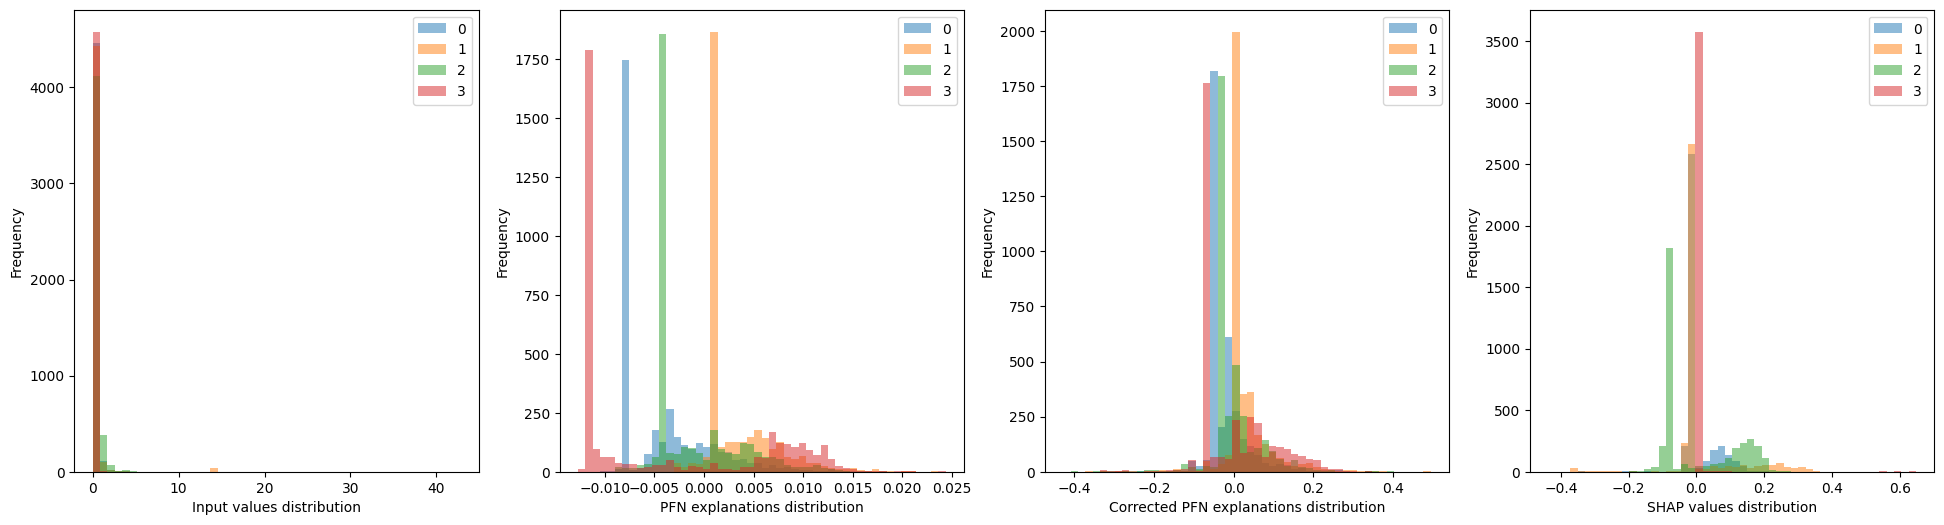

In [6]:
df_explanations = pd.DataFrame(
    explanations.astype(float), columns=df_train.columns.drop("target")
)
df_explanations["target"] = y_test
df_explanations_corrected = pd.DataFrame(
    explanations_corrected.astype(float), columns=df_train.columns.drop("target")
)
df_explanations_corrected["target"] = y_test
plot_explanations(df, df_explanations, df_explanations_corrected, df_shap)